# Model Training Notebook

This notebook is for training and evaluating machine learning models.

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

## 2. Load Data

In [2]:
# Load your dataset
df = pd.read_csv(r"C:\Users\DELL\Desktop\vscode\SentinelML\services\event_generator_service\data\transactions.csv")

# Display basic info
print(f"Dataset shape: {df.shape}")
print(df.head())

Dataset shape: (7483766, 24)
  transaction_id customer_id       card_number  \
0    TX_a0ad2a2a  CUST_72886  6646734767813109   
1    TX_3599c101  CUST_70474   376800864692727   
2    TX_a9461c6d  CUST_10715  5251909460951913   
3    TX_7be21fc4  CUST_16193   376079286931183   
4    TX_150f490b  CUST_87572  6172948052178810   

                          timestamp merchant_category merchant_type  \
0  2024-09-30 00:00:01.034820+00:00        Restaurant     fast_food   
1  2024-09-30 00:00:01.764464+00:00     Entertainment        gaming   
2  2024-09-30 00:00:02.273762+00:00           Grocery      physical   
3  2024-09-30 00:00:02.297466+00:00               Gas         major   
4  2024-09-30 00:00:02.544063+00:00        Healthcare       medical   

         merchant     amount currency    country  ...   device channel  \
0       Taco Bell     294.87      GBP         UK  ...  iOS App  mobile   
1           Steam    3368.97      BRL     Brazil  ...     Edge     web   
2     Whole Foods  10

In [3]:
print(df["customer_id"].nunique())

4869


## 3. Exploratory Data Analysis (EDA)

In [4]:
# Check for missing values
print("Missing values:")
print(df.isnull().sum())

# Data statistics
print("\nDataset Info:")
print(df.info())

# Class distribution (for fraud detection)
print("\nFraud Distribution:")
print(df['is_fraud'].value_counts())
print(df['is_fraud'].value_counts(normalize=True))

Missing values:
transaction_id         0
customer_id            0
card_number            0
timestamp              0
merchant_category      0
merchant_type          0
merchant               0
amount                 0
currency               0
country                0
city                   0
city_size              0
card_type              0
card_present           0
device                 0
channel                0
device_fingerprint     0
ip_address             0
distance_from_home     0
high_risk_merchant     0
transaction_hour       0
weekend_transaction    0
velocity_last_hour     0
is_fraud               0
dtype: int64

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 7483766 entries, 0 to 7483765
Data columns (total 24 columns):
 #   Column               Dtype  
---  ------               -----  
 0   transaction_id       str    
 1   customer_id          str    
 2   card_number          int64  
 3   timestamp            str    
 4   merchant_category    str    
 5   merchant_ty

### Customer-Level Analysis

In [5]:
# Aggregate customer-level statistics
customer_stats = df.groupby('customer_id').agg({
    'transaction_id': 'count',  # Number of transactions
    'amount': ['sum', 'mean', 'std', 'min', 'max'],  # Transaction amounts
    'is_fraud': 'sum',  # Number of fraudulent transactions
    'merchant': 'nunique',  # Unique merchants
    'country': 'nunique',  # Unique countries
}).reset_index()

# Flatten column names
customer_stats.columns = ['customer_id', 'num_transactions', 'total_amount', 
                          'avg_amount', 'std_amount', 'min_amount', 'max_amount', 
                          'num_fraud', 'unique_merchants', 'unique_countries']

# Calculate fraud rate per customer
customer_stats['fraud_rate'] = customer_stats['num_fraud'] / customer_stats['num_transactions']

print(f"Total unique customers: {len(customer_stats)}")
print("\nCustomer Statistics Summary:")
print(customer_stats.head())

Total unique customers: 4869

Customer Statistics Summary:
  customer_id  num_transactions  total_amount    avg_amount     std_amount  \
0  CUST_10000              1556   50900323.19  32712.289968  170741.544258   
1  CUST_10018              1280   47792204.67  37337.659898  167407.942563   
2  CUST_10022              1834   45031195.62  24553.541778  141098.043238   
3  CUST_10039              1572   54134452.63  34436.674701  227587.904069   
4  CUST_10102              1804   74577358.76  41339.999313  276885.578742   

   min_amount  max_amount  num_fraud  unique_merchants  unique_countries  \
0        0.05  4092679.04        311               105                12   
1        1.71  3136178.28        256               105                12   
2        0.05  2317382.21        366               105                12   
3        0.16  4476054.86        314               105                12   
4        0.07  5962927.35        360               105                12   

   fraud_rate  

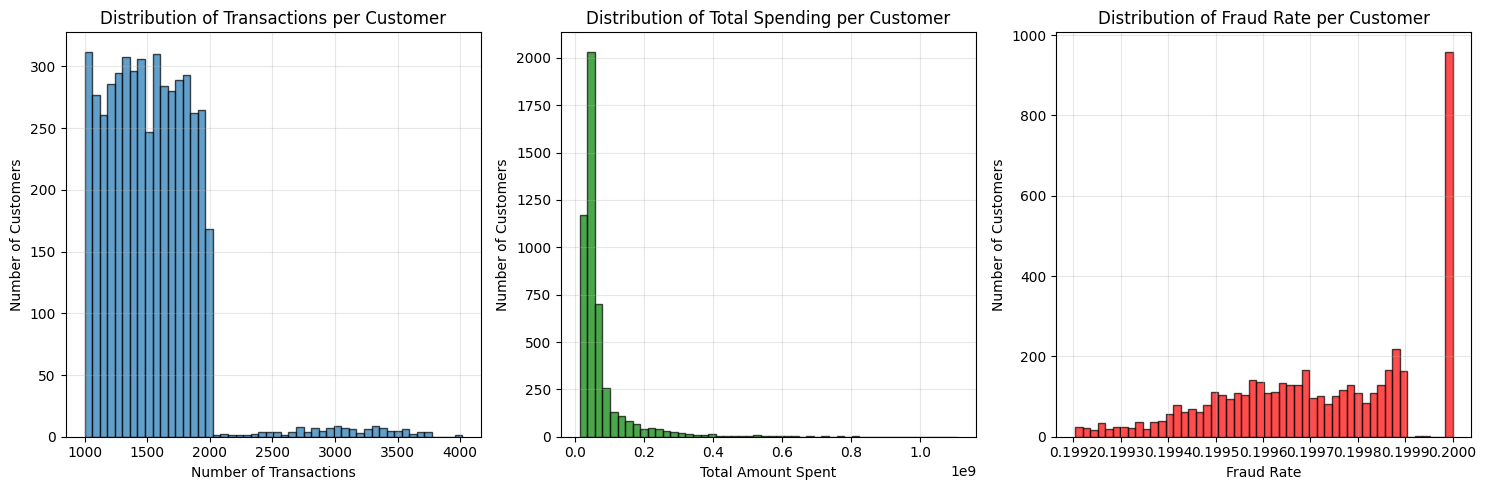

In [6]:
# Plot 1: Distribution of Number of Transactions per Customer
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.hist(customer_stats['num_transactions'], bins=50, edgecolor='black', alpha=0.7)
plt.xlabel('Number of Transactions')
plt.ylabel('Number of Customers')
plt.title('Distribution of Transactions per Customer')
plt.grid(True, alpha=0.3)

# Plot 2: Distribution of Total Amount Spent per Customer
plt.subplot(1, 3, 2)
plt.hist(customer_stats['total_amount'], bins=50, edgecolor='black', alpha=0.7, color='green')
plt.xlabel('Total Amount Spent')
plt.ylabel('Number of Customers')
plt.title('Distribution of Total Spending per Customer')
plt.grid(True, alpha=0.3)

# Plot 3: Fraud Rate per Customer
plt.subplot(1, 3, 3)
plt.hist(customer_stats['fraud_rate'], bins=50, edgecolor='black', alpha=0.7, color='red')
plt.xlabel('Fraud Rate')
plt.ylabel('Number of Customers')
plt.title('Distribution of Fraud Rate per Customer')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

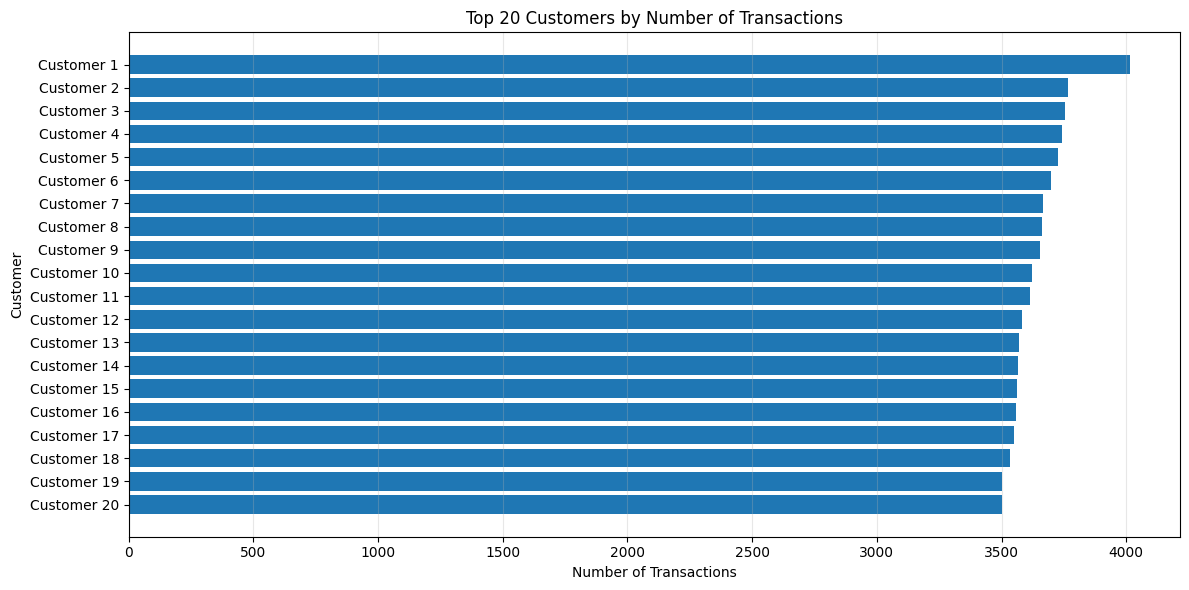


Top 20 Customers by Transaction Count:
     customer_id  num_transactions  total_amount  fraud_rate
4412  CUST_91730              4015  1.676193e+08    0.199502
770   CUST_24836              3767  5.410393e+08    0.199894
4195  CUST_87928              3756  5.410564e+08    0.199947
3781  CUST_81009              3744  1.076108e+08    0.199786
3586  CUST_77434              3728  1.117072e+08    0.199839
114   CUST_12255              3699  2.553939e+08    0.199784
2156  CUST_49715              3667  6.474806e+08    0.199891
4204  CUST_88176              3664  9.046116e+07    0.199782
3698  CUST_79625              3655  1.097085e+08    0.200000
1689  CUST_41245              3623  1.891307e+08    0.199834
2181  CUST_50255              3616  4.592548e+08    0.199668
3030  CUST_66586              3582  1.001491e+08    0.199888
2537  CUST_57249              3569  9.500764e+07    0.199776
353   CUST_16791              3565  9.967361e+07    0.199719
2565  CUST_57816              3563  2.395529e

In [7]:
# Top 20 Customers by Number of Transactions
top_customers_transactions = customer_stats.nlargest(20, 'num_transactions')

plt.figure(figsize=(12, 6))
plt.barh(range(len(top_customers_transactions)), top_customers_transactions['num_transactions'])
plt.yticks(range(len(top_customers_transactions)), 
           [f"Customer {i+1}" for i in range(len(top_customers_transactions))])
plt.xlabel('Number of Transactions')
plt.ylabel('Customer')
plt.title('Top 20 Customers by Number of Transactions')
plt.gca().invert_yaxis()
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

print("\nTop 20 Customers by Transaction Count:")
print(top_customers_transactions[['customer_id', 'num_transactions', 'total_amount', 'fraud_rate']].head(20))

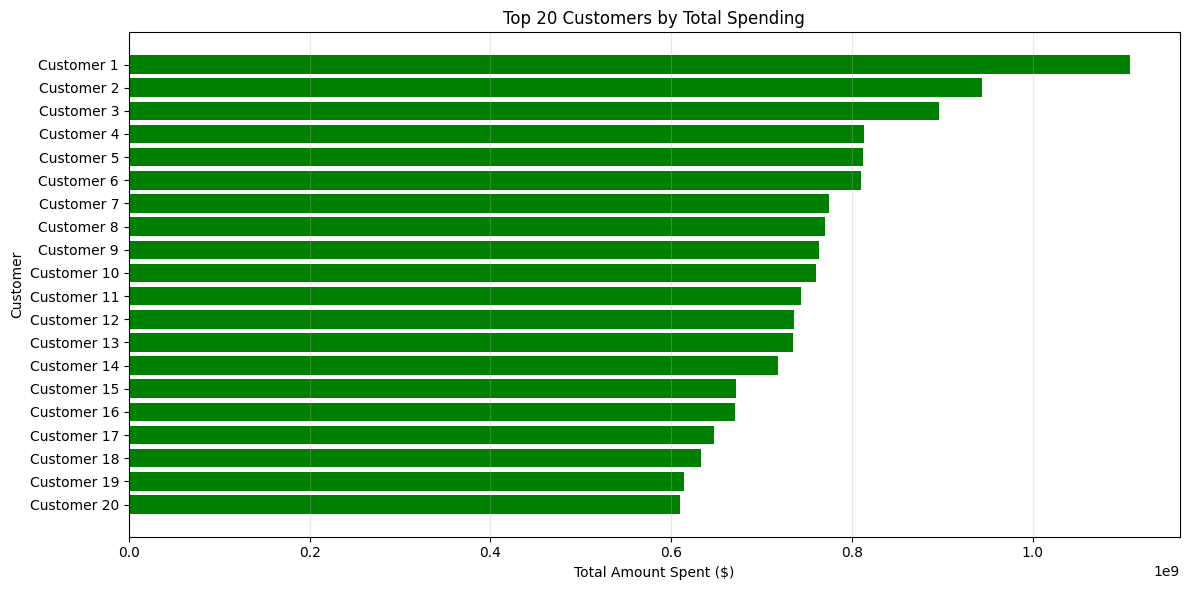


Top 20 Customers by Total Spending:
     customer_id  num_transactions  total_amount     avg_amount  fraud_rate
300   CUST_15792              2809  1.107544e+09  394284.069092    0.199715
4515  CUST_93550              1972  9.438005e+08  478600.665203    0.199797
1518  CUST_38134              1945  8.961895e+08  460765.823069    0.200000
2491  CUST_56417              1934  8.129329e+08  420337.582073    0.199586
3118  CUST_68420              1815  8.119670e+08  447364.720766    0.200000
1633  CUST_40215              1860  8.094951e+08  435212.434785    0.200000
3895  CUST_82782              1816  7.743107e+08  426382.562203    0.199890
3673  CUST_79168              1774  7.700944e+08  434100.553878    0.199549
2394  CUST_54419              1721  7.639201e+08  443881.534695    0.199884
2417  CUST_54779              1763  7.599119e+08  431033.415876    0.199660
3208  CUST_70100              1928  7.441530e+08  385971.449860    0.199689
1926  CUST_45368              1971  7.353907e+08  3

In [8]:
# Top 20 Customers by Total Spending
top_customers_spending = customer_stats.nlargest(20, 'total_amount')

plt.figure(figsize=(12, 6))
plt.barh(range(len(top_customers_spending)), top_customers_spending['total_amount'], color='green')
plt.yticks(range(len(top_customers_spending)), 
           [f"Customer {i+1}" for i in range(len(top_customers_spending))])
plt.xlabel('Total Amount Spent ($)')
plt.ylabel('Customer')
plt.title('Top 20 Customers by Total Spending')
plt.gca().invert_yaxis()
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

print("\nTop 20 Customers by Total Spending:")
print(top_customers_spending[['customer_id', 'num_transactions', 'total_amount', 'avg_amount', 'fraud_rate']].head(20))

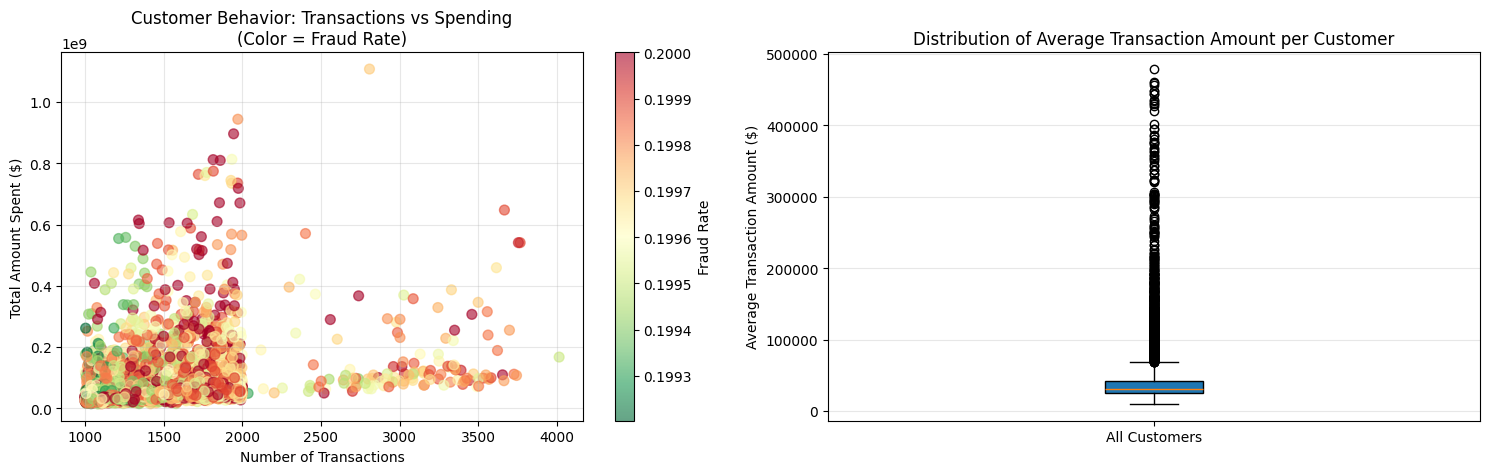


Customer Behavior Summary:
Average transactions per customer: 1537.02
Average total spending per customer: $73,661,352.36
Average fraud rate per customer: 19.97%

Customers with fraud: 4869
Customers without fraud: 0


In [9]:
# Customer Behavior: Transactions vs Total Amount (with fraud indication)
plt.figure(figsize=(15, 5))

# Scatter plot: Number of transactions vs Total amount
plt.subplot(1, 2, 1)
scatter = plt.scatter(customer_stats['num_transactions'], 
                     customer_stats['total_amount'],
                     c=customer_stats['fraud_rate'], 
                     cmap='RdYlGn_r', 
                     alpha=0.6,
                     s=50)
plt.xlabel('Number of Transactions')
plt.ylabel('Total Amount Spent ($)')
plt.title('Customer Behavior: Transactions vs Spending\n(Color = Fraud Rate)')
plt.colorbar(scatter, label='Fraud Rate')
plt.grid(True, alpha=0.3)

# Box plot: Average transaction amount distribution
plt.subplot(1, 2, 2)
plt.boxplot([customer_stats['avg_amount']], vert=True, patch_artist=True)
plt.ylabel('Average Transaction Amount ($)')
plt.title('Distribution of Average Transaction Amount per Customer')
plt.xticks([1], ['All Customers'])
plt.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Summary statistics
print("\nCustomer Behavior Summary:")
print(f"Average transactions per customer: {customer_stats['num_transactions'].mean():.2f}")
print(f"Average total spending per customer: ${customer_stats['total_amount'].mean():,.2f}")
print(f"Average fraud rate per customer: {customer_stats['fraud_rate'].mean():.2%}")
print(f"\nCustomers with fraud: {(customer_stats['num_fraud'] > 0).sum()}")
print(f"Customers without fraud: {(customer_stats['num_fraud'] == 0).sum()}")

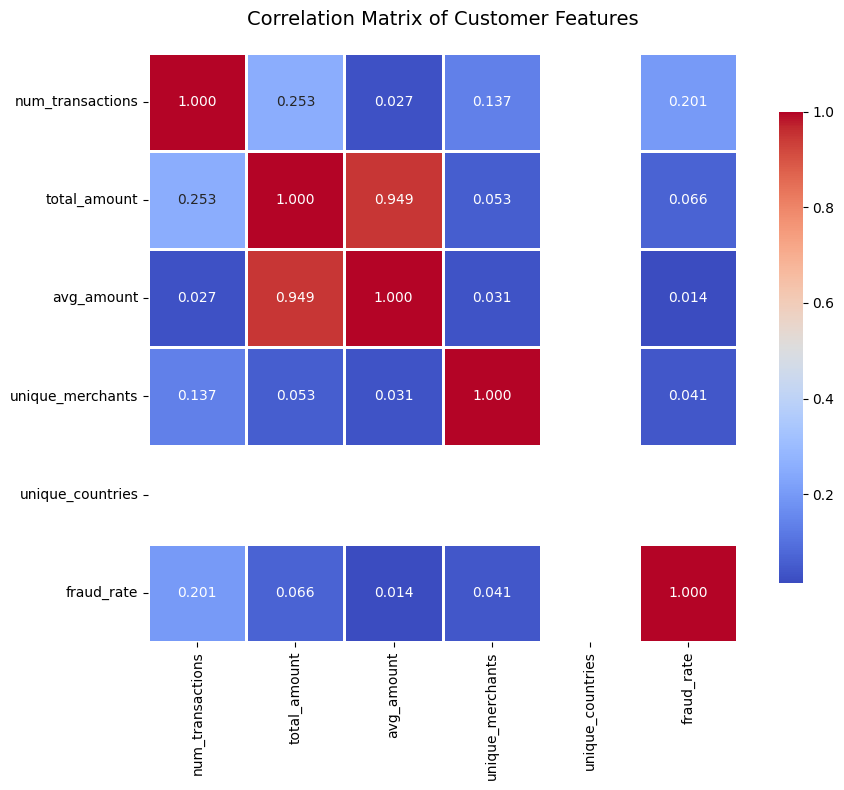


Key Insights from Correlation:
fraud_rate          1.000000
num_transactions    0.200503
total_amount        0.066176
unique_merchants    0.040748
avg_amount          0.014126
unique_countries         NaN
Name: fraud_rate, dtype: float64


In [10]:
# Correlation heatmap of customer features
customer_features = customer_stats[['num_transactions', 'total_amount', 'avg_amount', 
                                    'unique_merchants', 'unique_countries', 'fraud_rate']]

plt.figure(figsize=(10, 8))
correlation_matrix = customer_features.corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.3f', cmap='coolwarm', 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix of Customer Features', fontsize=14, pad=20)
plt.tight_layout()
plt.show()

print("\nKey Insights from Correlation:")
print(correlation_matrix['fraud_rate'].sort_values(ascending=False))

=== Fraud Rate by Card Present Status ===

              Fraud Count  Total Transactions  Fraud Rate  Fraud Rate %
card_present                                                           
False              843672             6832719      0.1235         12.35
True               651047              651047      1.0000        100.00



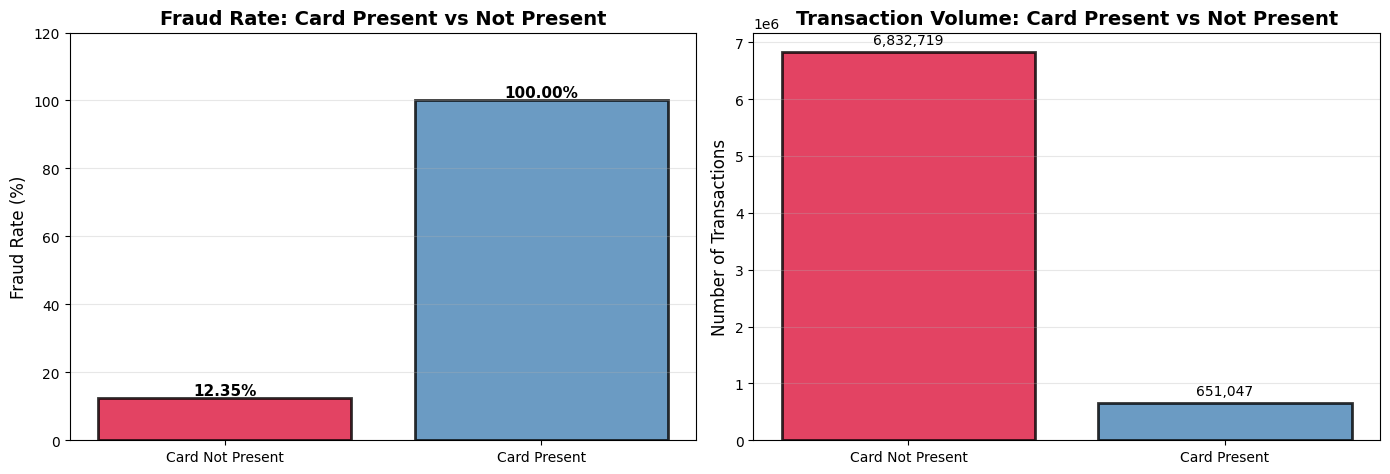


Key Insights:
  Card Present fraud rate:     100.00%
  Card Not Present fraud rate: 12.35%
  Risk Ratio (Not Present / Present): 0.12x


In [11]:

# Fraud Rate Analysis by Card Present Status
print("=== Fraud Rate by Card Present Status ===\n")

# Calculate fraud rates
fraud_by_card = df.groupby('card_present').agg({
    'is_fraud': ['sum', 'count', 'mean']
}).round(4)

fraud_by_card.columns = ['Fraud Count', 'Total Transactions', 'Fraud Rate']
fraud_by_card['Fraud Rate %'] = (fraud_by_card['Fraud Rate'] * 100).round(2)

print(fraud_by_card)
print()

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Fraud Rate Comparison
card_present_labels = ['Card Not Present', 'Card Present']
fraud_rates = df.groupby('card_present')['is_fraud'].mean() * 100

axes[0].bar(card_present_labels, fraud_rates, color=['crimson', 'steelblue'], 
            alpha=0.8, edgecolor='black', linewidth=2)
axes[0].set_ylabel('Fraud Rate (%)', fontsize=12)
axes[0].set_title('Fraud Rate: Card Present vs Not Present', fontsize=14, fontweight='bold')
axes[0].set_ylim(0, max(fraud_rates) * 1.2)
for i, v in enumerate(fraud_rates):
    axes[0].text(i, v + 1, f'{v:.2f}%', ha='center', fontsize=11, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='y')

# Plot 2: Transaction Count by Card Present
transaction_counts = df.groupby('card_present').size()
colors = ['crimson', 'steelblue']
axes[1].bar(card_present_labels, transaction_counts, color=colors, 
            alpha=0.8, edgecolor='black', linewidth=2)
axes[1].set_ylabel('Number of Transactions', fontsize=12)
axes[1].set_title('Transaction Volume: Card Present vs Not Present', fontsize=14, fontweight='bold')
for i, v in enumerate(transaction_counts):
    axes[1].text(i, v + max(transaction_counts)*0.02, f'{v:,}', ha='center', fontsize=10)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Risk ratio
card_present_fraud_rate = df[df['card_present'] == 1]['is_fraud'].mean()
card_not_present_fraud_rate = df[df['card_present'] == 0]['is_fraud'].mean()
risk_ratio = card_not_present_fraud_rate / (card_present_fraud_rate + 1e-6)

print(f"\nKey Insights:")
print(f"  Card Present fraud rate:     {card_present_fraud_rate:.2%}")
print(f"  Card Not Present fraud rate: {card_not_present_fraud_rate:.2%}")
print(f"  Risk Ratio (Not Present / Present): {risk_ratio:.2f}x")


## 4. Feature Engineering (Clean Version)

Single source of truth for features used by the model and evaluation.

In [23]:
# Build a clean, reusable feature table
work_df = df.copy()
work_df['timestamp'] = pd.to_datetime(work_df['timestamp'], errors='coerce')
work_df = work_df.dropna(subset=['timestamp', 'customer_id', 'is_fraud']).sort_values(['customer_id', 'timestamp']).reset_index(drop=True)

# Per-customer deviation features
work_df['amount_zscore'] = work_df.groupby('customer_id')['amount'].transform(lambda x: (x - x.mean()) / (x.std() + 1e-6))
work_df['distance_zscore'] = work_df.groupby('customer_id')['distance_from_home'].transform(lambda x: (x - x.mean()) / (x.std() + 1e-6))
work_df['hour_zscore'] = work_df.groupby('customer_id')['transaction_hour'].transform(lambda x: (x - x.mean()) / (x.std() + 1e-6))

# Behavior-change flags
work_df['is_new_country'] = (~work_df.groupby('customer_id')['country'].transform(lambda x: x.duplicated(keep='first'))).astype(int)
work_df['is_new_device'] = (~work_df.groupby('customer_id')['device_fingerprint'].transform(lambda x: x.duplicated(keep='first'))).astype(int)

# Contextual features
cat_avg = work_df.groupby('merchant_category')['amount'].transform('mean')
work_df['amount_vs_category'] = work_df['amount'] / (cat_avg + 1e-6)

customer_currency = work_df.groupby('customer_id')['currency'].transform(lambda x: x.mode().iloc[0] if not x.mode().empty else x.iloc[0])
work_df['is_foreign_currency'] = (work_df['currency'] != customer_currency).astype(int)

# Burst behavior
work_df['time_since_last_tx'] = work_df.groupby('customer_id')['timestamp'].transform(lambda x: x.diff().dt.total_seconds().fillna(0))
work_df['time_since_last_zscore'] = work_df.groupby('customer_id')['time_since_last_tx'].transform(lambda x: (x - x.mean()) / (x.std() + 1e-6))

FEATURES_FINAL = [
    'distance_zscore',
    'amount_vs_category',
    'hour_zscore',
    'is_foreign_currency',
    'amount_zscore',
    'is_new_country',
    'time_since_last_zscore',
    'is_new_device',
]

model_df = work_df.dropna(subset=FEATURES_FINAL + ['is_fraud']).copy()

print(f"Rows after feature prep: {len(model_df):,}")
print(f"Customers: {model_df['customer_id'].nunique():,}")
print(f"Fraud rate: {model_df['is_fraud'].mean():.2%}")
print(f"Feature count: {len(FEATURES_FINAL)}")

Rows after feature prep: 7,483,766
Customers: 4,869
Fraud rate: 19.97%
Feature count: 8


## 5. Quick Baseline Model (Development Only)

This is a quick sanity check. Final reported performance should come from Section 6 only.

In [24]:
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import average_precision_score, roc_auc_score

sample_size = min(150_000, len(model_df))
dev_sample = model_df.sample(n=sample_size, random_state=42) if len(model_df) > sample_size else model_df

X_dev = dev_sample[FEATURES_FINAL].values
y_dev = dev_sample['is_fraud'].astype(int).values

scaler_dev = StandardScaler()
X_dev_scaled = scaler_dev.fit_transform(X_dev)

iso_dev = IsolationForest(
    n_estimators=300,
    max_samples=256,
    contamination=max(0.001, float(np.mean(y_dev))),
    random_state=42,
    n_jobs=-1,
)
iso_dev.fit(X_dev_scaled)

dev_score = -iso_dev.decision_function(X_dev_scaled)

print('Development baseline (same-sample sanity check):')
print(f"PR-AUC:  {average_precision_score(y_dev, dev_score):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_dev, dev_score):.4f}")

Development baseline (same-sample sanity check):
PR-AUC:  0.5775
ROC-AUC: 0.8769


## 6. Honest Evaluation (Out-of-Time + Customer-Exclusive)

Rules:
- Train on older time windows, validate/test on newer windows.
- No customer overlap across splits.
- Tune threshold on validation only.
- Report final performance once on untouched test set.

In [27]:
from sklearn.metrics import (
    precision_recall_curve,
    average_precision_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
)

# -------------------------------
# 1) Robust split construction
# -------------------------------
base = model_df.sort_values('timestamp').reset_index(drop=True).copy()

# Primary attempt: strict time windows + customer de-overlap
candidate_cuts = [
    (0.55, 0.75), (0.60, 0.80), (0.65, 0.82),
    (0.70, 0.85), (0.75, 0.90), (0.80, 0.92),
]

best_time_split = None
for q_train, q_val in candidate_cuts:
    t1 = base['timestamp'].quantile(q_train)
    t2 = base['timestamp'].quantile(q_val)

    tr = base[base['timestamp'] <= t1].copy()
    va = base[(base['timestamp'] > t1) & (base['timestamp'] <= t2)].copy()
    te = base[base['timestamp'] > t2].copy()

    tr_customers = set(tr['customer_id'].unique())
    va = va[~va['customer_id'].isin(tr_customers)].copy()
    va_customers = set(va['customer_id'].unique())
    te = te[~te['customer_id'].isin(tr_customers.union(va_customers))].copy()

    score = min(len(va), len(te))
    if best_time_split is None or score > best_time_split['score']:
        best_time_split = {
            'method': 'time_windows_strict',
            'q_train': q_train,
            'q_val': q_val,
            'train': tr,
            'val': va,
            'test': te,
            'score': score,
        }

# Fallback: customer cohorts ordered by first-seen time.
# This preserves customer exclusivity and keeps temporal meaning at customer level.
first_seen = base.groupby('customer_id')['timestamp'].min().sort_values()
customers = first_seen.index.to_list()
n_cust = len(customers)

n_train = int(0.70 * n_cust)
n_val = int(0.15 * n_cust)

train_customers = set(customers[:n_train])
val_customers = set(customers[n_train:n_train + n_val])
test_customers = set(customers[n_train + n_val:])

cohort_train = base[base['customer_id'].isin(train_customers)].copy()
cohort_val = base[base['customer_id'].isin(val_customers)].copy()
cohort_test = base[base['customer_id'].isin(test_customers)].copy()

cohort_split = {
    'method': 'customer_cohort_first_seen',
    'q_train': None,
    'q_val': None,
    'train': cohort_train,
    'val': cohort_val,
    'test': cohort_test,
    'score': min(len(cohort_val), len(cohort_test)),
}

# Prefer strict time split when usable; otherwise use cohort fallback
if best_time_split is not None and best_time_split['score'] >= 200:
    best_split = best_time_split
else:
    best_split = cohort_split

train_eval = best_split['train']
val_eval = best_split['val']
test_eval = best_split['test']

print('=== Split Summary ===')
print(f"Method: {best_split['method']}")
if best_split['method'] == 'time_windows_strict':
    print(f"Quantiles: train<={best_split['q_train']:.2f}, val<={best_split['q_val']:.2f}")
else:
    print('Customers split by first-seen timestamp order (70/15/15).')
print(f"Train rows: {len(train_eval):,} | customers: {train_eval['customer_id'].nunique():,}")
print(f"Val rows:   {len(val_eval):,} | customers: {val_eval['customer_id'].nunique():,}")
print(f"Test rows:  {len(test_eval):,} | customers: {test_eval['customer_id'].nunique():,}")

assert len(set(train_eval['customer_id']) & set(val_eval['customer_id'])) == 0
assert len(set(train_eval['customer_id']) & set(test_eval['customer_id'])) == 0
assert len(set(val_eval['customer_id']) & set(test_eval['customer_id'])) == 0
print('Customer overlap check: PASSED')

if len(val_eval) == 0 or len(test_eval) == 0:
    raise ValueError(
        'Could not create non-empty validation/test with customer exclusivity. '
        'Please reduce strictness or provide more data.'
    )

if len(val_eval) < 200 or len(test_eval) < 200:
    print('Warning: Validation/Test are small; metrics may be noisy.')

# -------------------------------
# 2) Fit on train only
# -------------------------------
X_train = train_eval[FEATURES_FINAL].values
y_train = train_eval['is_fraud'].astype(int).values
X_val = val_eval[FEATURES_FINAL].values
y_val = val_eval['is_fraud'].astype(int).values
X_test = test_eval[FEATURES_FINAL].values
y_test = test_eval['is_fraud'].astype(int).values

scaler_final = StandardScaler()
X_train_s = scaler_final.fit_transform(X_train)
X_val_s = scaler_final.transform(X_val)
X_test_s = scaler_final.transform(X_test)

iso_final = IsolationForest(
    n_estimators=300,
    max_samples=256,
    contamination=max(0.001, float(np.mean(y_train))),
    random_state=42,
    n_jobs=-1,
)
iso_final.fit(X_train_s)

val_score = -iso_final.decision_function(X_val_s)
test_score = -iso_final.decision_function(X_test_s)

# -------------------------------
# 3) Tune threshold on validation
# -------------------------------
TARGET_PRECISION = 0.80

if len(np.unique(y_val)) < 2:
    threshold = float(np.quantile(val_score, 0.90))
    selection_rule = 'Fallback: validation has one class, using 90th percentile threshold'
    val_precision = np.nan
    val_recall = np.nan
else:
    prec, rec, thr = precision_recall_curve(y_val, val_score)
    prec_t, rec_t = prec[:-1], rec[:-1]

    if len(thr) == 0:
        threshold = float(np.quantile(val_score, 0.90))
        selection_rule = 'Fallback: empty threshold grid, using 90th percentile threshold'
        val_precision = np.nan
        val_recall = np.nan
    else:
        valid_idx = np.where(prec_t >= TARGET_PRECISION)[0]
        if len(valid_idx) > 0:
            idx = valid_idx[np.argmax(rec_t[valid_idx])]
            selection_rule = f"Max recall with precision >= {TARGET_PRECISION:.2f}"
        else:
            idx = int(np.argmax(prec_t))
            selection_rule = 'Fallback: maximum precision on validation'

        threshold = float(thr[idx])
        val_precision = float(prec_t[idx])
        val_recall = float(rec_t[idx])


def safe_auc(metric_fn, y_true, score):
    return float(metric_fn(y_true, score)) if len(np.unique(y_true)) >= 2 else np.nan

print('\n=== Threshold Selection (Validation only) ===')
print(f"Rule: {selection_rule}")
print(f"Threshold: {threshold:.6f}")
print(f"Validation precision: {val_precision if np.isnan(val_precision) else f'{val_precision:.4f}'}")
print(f"Validation recall:    {val_recall if np.isnan(val_recall) else f'{val_recall:.4f}'}")
print(f"Validation PR-AUC:    {safe_auc(average_precision_score, y_val, val_score):.4f}" if len(np.unique(y_val)) >= 2 else "Validation PR-AUC:    N/A (single-class y_val)")
print(f"Validation ROC-AUC:   {safe_auc(roc_auc_score, y_val, val_score):.4f}" if len(np.unique(y_val)) >= 2 else "Validation ROC-AUC:   N/A (single-class y_val)")

# -------------------------------
# 4) Evaluate helper with business cost
# -------------------------------
COST_FN = 200.0
COST_FP = 5.0

def evaluate_split(y_true, score, threshold, split_name):
    y_pred = (score >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    precision = tp / (tp + fp + 1e-9)
    recall = tp / (tp + fn + 1e-9)
    f1 = 2 * precision * recall / (precision + recall + 1e-9)
    pr_auc = safe_auc(average_precision_score, y_true, score)
    roc_auc = safe_auc(roc_auc_score, y_true, score)

    total_cost = fn * COST_FN + fp * COST_FP

    print(f"\n=== {split_name} ===")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1:        {f1:.4f}")
    print(f"PR-AUC:    {pr_auc:.4f}" if not np.isnan(pr_auc) else "PR-AUC:    N/A (single-class labels)")
    print(f"ROC-AUC:   {roc_auc:.4f}" if not np.isnan(roc_auc) else "ROC-AUC:   N/A (single-class labels)")
    print(f"TN={tn:,} FP={fp:,} FN={fn:,} TP={tp:,}")
    print(f"Business cost (FN*{COST_FN:.0f} + FP*{COST_FP:.0f}): {total_cost:,.2f}")

    return {
        'split': split_name,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'pr_auc': pr_auc,
        'roc_auc': roc_auc,
        'business_cost': total_cost,
        'rows': len(y_true),
    }

val_metrics = evaluate_split(y_val, val_score, threshold, 'Validation')

print('\nFinal test remains untouched until this point. Evaluating once now...')
test_metrics = evaluate_split(y_test, test_score, threshold, 'Final Test (Untouched)')

summary = pd.DataFrame([val_metrics, test_metrics])
print('\n=== Final Summary ===')
display(summary)

if len(np.unique(y_test)) >= 2:
    print('\nClassification report on final test:')
    print(classification_report(y_test, (test_score >= threshold).astype(int), target_names=['Normal', 'Fraud']))
else:
    print('\nClassification report skipped: final test labels contain one class only.')

=== Split Summary ===
Method: customer_cohort_first_seen
Customers split by first-seen timestamp order (70/15/15).
Train rows: 5,384,031 | customers: 3,408
Val rows:   1,086,843 | customers: 730
Test rows:  1,012,892 | customers: 731
Customer overlap check: PASSED

=== Threshold Selection (Validation only) ===
Rule: Max recall with precision >= 0.80
Threshold: 0.136899
Validation precision: 0.8000
Validation recall:    0.0901
Validation PR-AUC:    0.5913
Validation ROC-AUC:   0.8865

=== Validation ===
Precision: 0.8000
Recall:    0.0901
F1:        0.1620
PR-AUC:    0.5913
ROC-AUC:   0.8865
TN=864,881 FP=4,891 FN=197,505 TP=19,566
Business cost (FN*200 + FP*5): 39,525,455.00

Final test remains untouched until this point. Evaluating once now...

=== Final Test (Untouched) ===
Precision: 0.7985
Recall:    0.0892
F1:        0.1604
PR-AUC:    0.5948
ROC-AUC:   0.8903
TN=806,049 FP=4,553 FN=184,251 TP=18,039
Business cost (FN*200 + FP*5): 36,872,965.00

=== Final Summary ===


,split,precision,recall,f1,pr_auc,roc_auc,business_cost,rows
0,Validation,0.800016,0.090136,0.162018,0.591294,0.886545,39525455.0,1086843
1,Final Test (Untouched),0.798468,0.089174,0.160431,0.594824,0.890341,36872965.0,1012892



Classification report on final test:
              precision    recall  f1-score   support

      Normal       0.81      0.99      0.90    810602
       Fraud       0.80      0.09      0.16    202290

    accuracy                           0.81   1012892
   macro avg       0.81      0.54      0.53   1012892
weighted avg       0.81      0.81      0.75   1012892



## 7. Save Model

In [21]:
# Save trained model
# import joblib
# joblib.dump(model, 'model.pkl')

# Or using pickle
# import pickle
# with open('model.pkl', 'wb') as f:
#     pickle.dump(model, f)

## 8. Experiment Tracking

Document your experiments:
- Model type:
- Hyperparameters:
- Training date:
- Performance metrics:
- Notes: